In [132]:
import sys

sys.path.append("..")
import os

import matplotlib.pyplot as plt
import polars as pl
import torch
from PIL import Image
from transformers import AutoProcessor
import json

from src.geotir.model import GeoTIRModel
from src.utils import get_device, read_index

DEVICE = get_device()
BASEPATH = "/Users/affahrizain/projects/phd-research/dataset/geotir/gldv2-full"
MODEL_PATH = "../checkpoints/geotir/ckpt_best.pt"
INDEX_PATH = "../index/landmark_poi"
HF_CLIP = "openai/clip-vit-large-patch14"

In [131]:
entities = pl.read_csv("../dataset/csv/entities.csv").with_columns(
    pl.col("valid_pov_neighbor")
    .str.split(",")
    .list.eval(pl.element().filter(pl.element() != "").cast(pl.Int64))
)
spots = pl.read_csv("../dataset/csv/tower_spots.csv").select(
    ["id", "category", "latitude", "longitude", "img_id", "cluster_id"]
)

In [37]:
index, meta = read_index(INDEX_PATH)
meta = pl.DataFrame(meta["metadata"])

In [14]:
processor = AutoProcessor.from_pretrained(HF_CLIP)
model = GeoTIRModel().to(DEVICE)
ckpt = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model = model.eval()
model = torch.compile(model)

Loading weights: 100%|██████████| 590/590 [00:00<00:00, 8426.63it/s]


trainable params: 2,162,688 || all params: 429,779,201 || trainable%: 0.5032


In [149]:
query_text = "a red tall tower in Tokyo, Japan"
query = processor(
    text=[query_text], return_tensors="pt", padding=True, truncation=True, max_length=77
).to(DEVICE)
with torch.no_grad():
    out = model.encode_texts(**query).cpu().float()

In [91]:
score, ix = index.search(out, 100)
score, ix = score.flatten(), ix.flatten()

In [151]:
poi = (
    meta[ix]
    .with_columns(pl.Series(score).alias("score"))
    .group_by("entity_id")
    .agg(pl.all().sort_by("score").last())
    .join(
        entities.select(["entity_id", "valid_pov_neighbor"]), on="entity_id", how="left"
    )
    .sort("score", descending=True)
)

In [139]:
result = []
for row in poi.to_dicts():
    itemdict = row.copy()
    itemdict["spots"] = []
    if row["valid_pov_neighbor"]: 
        for clstr_id in row["valid_pov_neighbor"]:
            itemdict["spots"].extend(
                spots.filter(pl.col("cluster_id") == clstr_id).to_dicts()
            )

    result.append(itemdict)

with open("retrieval_result.json", "w") as f:
    f.write(json.dumps({"data": result}))

In [177]:
import plotly.colors as pc
import plotly.graph_objects as go
from collections import defaultdict

palette = pc.qualitative.Plotly

top5_result = sorted(result, key=lambda r: r["score"], reverse=True)[:5]

# Build cluster_id → color map across all spots in top-5
all_cluster_ids = sorted(set(
    s["cluster_id"] for item in top5_result for s in item["spots"] if s["cluster_id"] != -1
))
cluster_color_map = {cid: palette[i % len(palette)] for i, cid in enumerate(all_cluster_ids)}
cluster_color_map[-1] = "lightgray"

fig = go.Figure()

# Group spots by cluster_id, draw with lower opacity
cluster_spots = defaultdict(list)
for item in top5_result:
    for s in item["spots"]:
        cluster_spots[s["cluster_id"]].append(s)

for cid, spots_in_cluster in cluster_spots.items():
    color = cluster_color_map[cid]
    fig.add_trace(
        go.Scattermap(
            lat=[s["latitude"] for s in spots_in_cluster],
            lon=[s["longitude"] for s in spots_in_cluster],
            mode="markers",
            marker=dict(size=6, color=color, opacity=0.3),
            name=f"Cluster {cid}",
            legendgroup=f"cluster_{cid}",
            hovertemplate="POV<br>Cluster: %{customdata[0]}<br>ID: %{customdata[1]}<extra></extra>",
            customdata=[[s["cluster_id"], s["id"]] for s in spots_in_cluster],
        )
    )

# Group POIs by their color (based on first cluster), then add one trace per color
poi_by_color = defaultdict(list)
for r in top5_result:
    if r["spots"]:
        first_cluster = r["spots"][0]["cluster_id"]
        color = cluster_color_map[first_cluster]
        poi_by_color[(color, first_cluster)].append(r)
    else:
        poi_by_color[("#2893c1", None)].append(r)

for (color, cid), pois in poi_by_color.items():
    label = f"POI (Cluster {cid})" if cid is not None else "POI (no spots)"
    fig.add_trace(
        go.Scattermap(
            lat=[r["latitude"] for r in pois],
            lon=[r["longitude"] for r in pois],
            mode="markers",
            marker=dict(size=14, color=color, opacity=1.0, symbol="star"),
            name=label,
            legendgroup=f"cluster_{cid}",
            showlegend=False,
            hovertemplate=(
                "%{customdata[0]}<br>"
                "Category: %{customdata[1]}<br>"
                "Score: %{customdata[2]:.4f}<extra></extra>"
            ),
            customdata=[[r["poi_name"], r["category"], r["score"]] for r in pois],
        )
    )

fig.update_layout(
    title=f"Query: {query_text} → Top-5 POIs",
    map=dict(center={"lat": 35.6895, "lon": 139.7517}, zoom=12),
    height=500,
    width=800,
    margin=dict(l=10, r=10, t=75, b=10),
    legend=dict(x=0, y=1),
)

fig.show()


In [178]:
import plotly.colors as pc
import plotly.graph_objects as go
from collections import defaultdict

palette = pc.qualitative.Plotly

# Build cluster_id → color map across all spots
all_cluster_ids = sorted(set(
    s["cluster_id"] for item in result for s in item["spots"] if s["cluster_id"] != -1
))
cluster_color_map = {cid: palette[i % len(palette)] for i, cid in enumerate(all_cluster_ids)}
cluster_color_map[-1] = "lightgray"

fig = go.Figure()

# Group spots by cluster_id, draw with lower opacity
cluster_spots = defaultdict(list)
for item in result:
    for s in item["spots"]:
        cluster_spots[s["cluster_id"]].append(s)

for cid, spots_in_cluster in cluster_spots.items():
    color = cluster_color_map[cid]
    fig.add_trace(
        go.Scattermap(
            lat=[s["latitude"] for s in spots_in_cluster],
            lon=[s["longitude"] for s in spots_in_cluster],
            mode="markers",
            marker=dict(size=6, color=color, opacity=0.3),
            name=f"Cluster {cid}",
            legendgroup=f"cluster_{cid}",
            hovertemplate="POV<br>Cluster: %{customdata[0]}<br>ID: %{customdata[1]}<extra></extra>",
            customdata=[[s["cluster_id"], s["id"]] for s in spots_in_cluster],
        )
    )

# Group POIs by their color (based on first cluster), then add one trace per color
poi_by_color = defaultdict(list)
for r in result:
    if r["spots"]:
        first_cluster = r["spots"][0]["cluster_id"]
        color = cluster_color_map[first_cluster]
        poi_by_color[(color, first_cluster)].append(r)
    else:
        poi_by_color[("#2893c1", None)].append(r)

for (color, cid), pois in poi_by_color.items():
    label = f"POI (Cluster {cid})" if cid is not None else "POI (no spots)"
    fig.add_trace(
        go.Scattermap(
            lat=[r["latitude"] for r in pois],
            lon=[r["longitude"] for r in pois],
            mode="markers",
            marker=dict(size=14, color=color, opacity=1.0, symbol="star"),
            name=label,
            legendgroup=f"cluster_{cid}",
            showlegend=False,
            hovertemplate=(
                "%{customdata[0]}<br>"
                "Category: %{customdata[1]}<br>"
                "Score: %{customdata[2]:.4f}<extra></extra>"
            ),
            customdata=[[r["poi_name"], r["category"], r["score"]] for r in pois],
        )
    )

fig.update_layout(
    title=f"Query: {query_text} → All POIs",
    map=dict(center={"lat": 35.6895, "lon": 139.7517}, zoom=12),
    height=500,
    width=800,
    margin=dict(l=10, r=10, t=75, b=10),
    legend=dict(x=0, y=1),
)

fig.show()


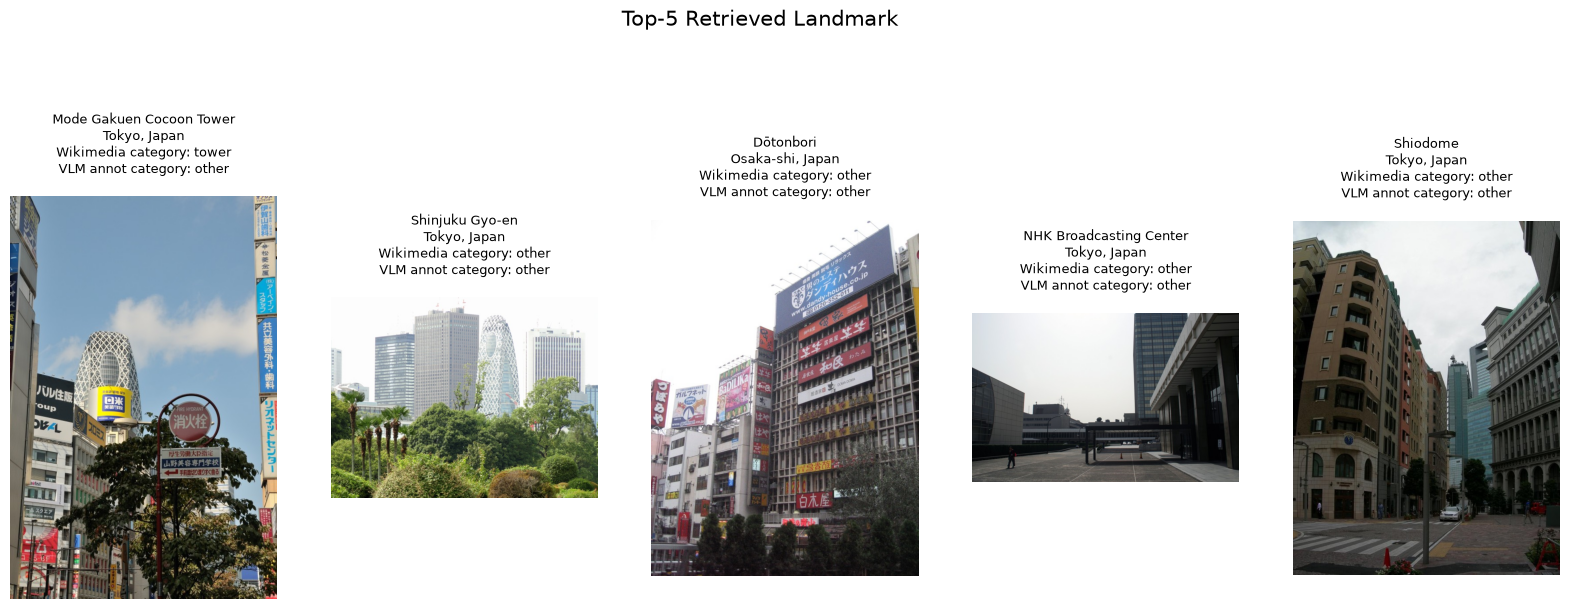

In [174]:
# top-5 distinct retrieved landmark
fig, ax = plt.subplots(1, 5, figsize=(20, 8))
for i, it in enumerate(poi.head().to_dicts()):
    ax[i].imshow(Image.open(os.path.join(BASEPATH, it["src"], it["id"] + ".jpg")))
    ax[i].axis("off")
    ax[i].set_title(
        f"{it['poi_name']}\n"
        f"{it['city']}, {it['country']}\n"
        f"Wikimedia category: {it['category']}\n"
        f"VLM annot category: {"other" if it['pred_label'] == "non_landmark" else it["pred_label"]}\n",
        fontsize=9,
    )
plt.suptitle("Top-5 Retrieved Landmark", fontsize=15)
plt.show()